In [31]:
import os, sys, platform, random, time, copy
from pathlib import Path
from datetime import datetime
import torch
import torchvision
import pandas as pd
import numpy as np
import sklearn
import PIL
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import zipfile
import shutil

print('تم استيراد كل المكتبات الأساسية بنجاح')

تم استيراد كل المكتبات الأساسية بنجاح


In [32]:
cuda_available = torch.cuda.is_available()
print('هل CUDA متاحة؟', cuda_available)
if not cuda_available:
    raise RuntimeError('GPU غير متاح. تحققي من إعدادات Colab ثم أعيدي تشغيل الخلية.')
print('اسم GPU:', torch.cuda.get_device_name(0))
print('إصدار CUDA:', torch.version.cuda)
DEVICE = torch.device('cuda')
print('الجهاز المعتمد:', DEVICE)

هل CUDA متاحة؟ True
اسم GPU: Tesla T4
إصدار CUDA: 12.8
الجهاز المعتمد: cuda


In [33]:
PROJECT_DIR = Path('/content/pneumonia_resnet18_work')
DATA_DIR = PROJECT_DIR / 'data'
SPLIT_DIR = PROJECT_DIR / 'splits'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
REPORTS_DIR = PROJECT_DIR / 'reports'
FIGURES_DIR = PROJECT_DIR / 'figures'
LOGS_DIR = PROJECT_DIR / 'logs'
EXPERIMENTS_DIR = PROJECT_DIR / 'experiments'
for folder in [PROJECT_DIR, DATA_DIR, SPLIT_DIR, CHECKPOINT_DIR, REPORTS_DIR, FIGURES_DIR, LOGS_DIR, EXPERIMENTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print('تم إنشاء مجلدات المشروع')

تم إنشاء مجلدات المشروع


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
from pathlib import Path
DRIVE_ROOT = Path('/content/drive/MyDrive')
zip_files = list(DRIVE_ROOT.rglob('*.zip'))
print('عدد ملفات ZIP:', len(zip_files))
for path in zip_files:
    print(f'{path.stat().st_size/(1024*1024):8.2f} MB   {path}')

عدد ملفات ZIP: 1
 6704.47 MB   /content/drive/MyDrive/pneumonia_resnet18/data_raw/mendeley_dataset.zip.zip


In [36]:
import shutil
from pathlib import Path

# ============================================================
# قبل التشغيل: عدّلي هذا المسار ليطابق موقع قاعدة البيانات
# في حساب Google Drive الخاص بك. راجعي README.md لمصدر
# تنزيل قاعدة البيانات الرسمي وطريقة رفعها إلى Drive.
# ============================================================
DRIVE_ZIP_PATH = '/content/drive/MyDrive/pneumonia_resnet18/data_raw/mendeley_dataset.zip.zip'
LOCAL_ZIP_PATH = '/content/dataset.zip'

shutil.copy(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)
print('تم نسخ الملف محليًا:', LOCAL_ZIP_PATH)
print('الحجم:', Path(LOCAL_ZIP_PATH).stat().st_size / (1024*1024), 'MB')

تم نسخ الملف محليًا: /content/dataset.zip
الحجم: 6704.472677230835 MB


In [37]:
drive.flush_and_unmount()
print('تم فصل Drive — بقية التنفيذ من /content فقط.')

تم فصل Drive — بقية التنفيذ من /content فقط.


In [38]:
print('الملف سليم؟', zipfile.is_zipfile(LOCAL_ZIP_PATH))

الملف سليم؟ True


In [39]:
ZIP_PATH = Path(LOCAL_ZIP_PATH)
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)
print('تم فك الضغط داخل:', DATA_DIR)

تم فك الضغط داخل: /content/pneumonia_resnet18_work/data


In [40]:
all_items = list(DATA_DIR.rglob('*'))
print('عدد العناصر:', len(all_items))
for path in all_items[:10]:
    print(('DIR ' if path.is_dir() else 'FILE'), path.relative_to(DATA_DIR))

عدد العناصر: 7400
DIR  __MACOSX
FILE code2017.zip
DIR  chest_xray
FILE ChestXRay2017.zip
FILE OCT2017.tar.gz
DIR  __MACOSX/chest_xray
FILE chest_xray/.DS_Store
DIR  chest_xray/test
DIR  chest_xray/train
FILE chest_xray/test/.DS_Store


In [41]:
CHEST_XRAY_ZIP = DATA_DIR / 'ChestXRay2017.zip'
with zipfile.ZipFile(CHEST_XRAY_ZIP, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)
print('تم فك ضغط ChestXRay2017.zip')

تم فك ضغط ChestXRay2017.zip


In [42]:
normal_dirs = [p for p in DATA_DIR.rglob('*') if p.is_dir() and p.name.upper() == 'NORMAL' and '__MACOSX' not in p.parts]
pneumonia_dirs = [p for p in DATA_DIR.rglob('*') if p.is_dir() and p.name.upper() == 'PNEUMONIA' and '__MACOSX' not in p.parts]

print('مجلدات NORMAL:')
for p in normal_dirs:
    print(p)

print('\nمجلدات PNEUMONIA:')
for p in pneumonia_dirs:
    print(p)

if not normal_dirs or not pneumonia_dirs:
    raise FileNotFoundError('لم يتم العثور على المجلدين')

مجلدات NORMAL:
/content/pneumonia_resnet18_work/data/chest_xray/test/NORMAL
/content/pneumonia_resnet18_work/data/chest_xray/train/NORMAL

مجلدات PNEUMONIA:
/content/pneumonia_resnet18_work/data/chest_xray/test/PNEUMONIA
/content/pneumonia_resnet18_work/data/chest_xray/train/PNEUMONIA


In [43]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
records = []
for class_name, class_id, class_dirs in [('NORMAL', 0, normal_dirs), ('PNEUMONIA', 1, pneumonia_dirs)]:
    for class_dir in class_dirs:
        for image_path in class_dir.rglob('*'):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({'image_path': str(image_path), 'label': class_name, 'label_id': class_id})

manifest_df = pd.DataFrame(records).drop_duplicates('image_path').reset_index(drop=True)
if manifest_df.empty:
    raise ValueError('لم توجد صور صالحة')

print('العدد الكلي:', len(manifest_df))
print(manifest_df['label'].value_counts())

العدد الكلي: 5856
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


In [44]:
from tqdm.auto import tqdm

bad_images = []
for image_path in tqdm(manifest_df['image_path'], desc='فحص الصور'):
    try:
        with Image.open(image_path) as image:
            image.verify()
    except Exception as error:
        bad_images.append({'image_path': image_path, 'error': str(error)})

bad_images_df = pd.DataFrame(bad_images)
print('تم فحص:', len(manifest_df))
print('الصور التالفة:', len(bad_images_df))
if not bad_images_df.empty:
    display(bad_images_df.head())

فحص الصور:   0%|          | 0/5856 [00:00<?, ?it/s]

تم فحص: 5856
الصور التالفة: 0


In [45]:
bad_paths = set(bad_images_df['image_path'].tolist()) if not bad_images_df.empty else set()
clean_manifest_df = manifest_df[~manifest_df['image_path'].isin(bad_paths)].reset_index(drop=True)

print('العدد النهائي:', len(clean_manifest_df))
print(clean_manifest_df['label'].value_counts())

CLEAN_MANIFEST_PATH = PROJECT_DIR / 'clean_manifest.csv'
clean_manifest_df.to_csv(CLEAN_MANIFEST_PATH, index=False, encoding='utf-8-sig')
manifest_df.to_csv(REPORTS_DIR / 'dataset_manifest.csv', index=False, encoding='utf-8-sig')
bad_images_df.to_csv(REPORTS_DIR / 'bad_images.csv', index=False, encoding='utf-8-sig')
print('تم الحفظ')

العدد النهائي: 5856
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64
تم الحفظ


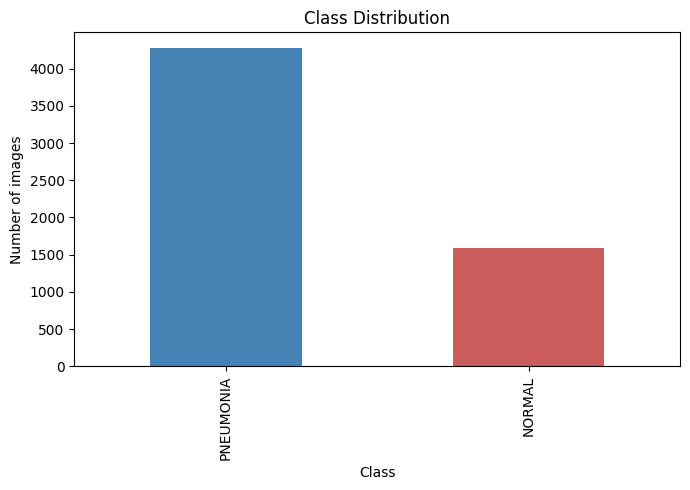

In [46]:
counts = clean_manifest_df['label'].value_counts()
plt.figure(figsize=(7, 5))
counts.plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Class Distribution'); plt.xlabel('Class'); plt.ylabel('Number of images')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=200, bbox_inches='tight')
plt.show(); plt.close()

In [47]:
from sklearn.model_selection import train_test_split
SEED = 42

train_df, temp_df = train_test_split(clean_manifest_df, test_size=0.30, stratify=clean_manifest_df['label_id'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_id'], random_state=SEED)

train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))

Train: 4099 | Val: 878 | Test: 879


In [48]:
def split_summary(name, df):
    counts = df['label'].value_counts()
    return {'split': name, 'total': len(df), 'NORMAL': int(counts.get('NORMAL', 0)), 'PNEUMONIA': int(counts.get('PNEUMONIA', 0))}

split_summary_df = pd.DataFrame([split_summary('train', train_df), split_summary('validation', val_df), split_summary('test', test_df)])
display(split_summary_df)

,split,total,NORMAL,PNEUMONIA
0,train,4099,1108,2991
1,validation,878,237,641
2,test,879,238,641


In [49]:
train_paths, val_paths, test_paths = set(train_df['image_path']), set(val_df['image_path']), set(test_df['image_path'])
print('Train∩Val:', len(train_paths & val_paths), '| Train∩Test:', len(train_paths & test_paths), '| Val∩Test:', len(val_paths & test_paths))
if train_paths & val_paths or train_paths & test_paths or val_paths & test_paths:
    raise ValueError('يوجد تداخل')
print('لا يوجد تداخل')

Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0
لا يوجد تداخل


In [50]:
TRAIN_PATH, VAL_PATH, TEST_PATH = SPLIT_DIR / 'train.csv', SPLIT_DIR / 'val.csv', SPLIT_DIR / 'test.csv'
train_df.to_csv(TRAIN_PATH, index=False, encoding='utf-8-sig')
val_df.to_csv(VAL_PATH, index=False, encoding='utf-8-sig')
test_df.to_csv(TEST_PATH, index=False, encoding='utf-8-sig')
split_summary_df.to_csv(REPORTS_DIR / 'split_summary.csv', index=False, encoding='utf-8-sig')
print('تم الحفظ — التقسيم مُجمَّد نهائيًا')

تم الحفظ — التقسيم مُجمَّد نهائيًا


In [51]:
from torchvision import transforms
IMAGE_SIZE, BATCH_SIZE = 224, 32

basic_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
additional_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.Grayscale(num_output_channels=3),
    transforms.ColorJitter(brightness=0.10, contrast=0.20, saturation=0.0, hue=0.0),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print('تم التعريف')

تم التعريف


In [52]:
from torch.utils.data import Dataset, DataLoader

class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['label_id'])
        if self.transform is not None: image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

def make_loaders(transform):
    train_ds, val_ds, test_ds = PneumoniaDataset(train_df, transform), PneumoniaDataset(val_df, transform), PneumoniaDataset(test_df, transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, val_loader, test_loader

train_loader_basic, val_loader_basic, test_loader_basic = make_loaders(basic_transform)
train_loader_additional, val_loader_additional, test_loader_additional = make_loaders(additional_transform)
print('تم الإنشاء')

تم الإنشاء


In [53]:
images, labels = next(iter(train_loader_basic))
print(images.shape, labels.shape, labels.unique())

torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor([0, 1])


In [54]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train(); running_loss = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images); loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item(); total += labels.size(0)
    return running_loss/total, correct/total

def validate_one_epoch(model, loader, criterion, device):
    model.eval(); running_loss = correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images); loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item(); total += labels.size(0)
    return running_loss/total, correct/total

print('تم تعريف دوال التدريب والتحقق')

تم تعريف دوال التدريب والتحقق


In [55]:
import torch.nn as nn
from torchvision import models
NUM_CLASSES, LEARNING_RATE, EPOCHS = 2, 0.0001, 10

def build_model(transfer_learning):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) if transfer_learning else models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(DEVICE)

def run_experiment(experiment_name, transfer_learning, transform, train_loader, val_loader):
    experiment_dir = EXPERIMENTS_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    model = build_model(transfer_learning)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_val_accuracy, best_epoch = -1.0, 0
    best_model_state = copy.deepcopy(model.state_dict())
    history = []
    for epoch in range(EPOCHS):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, DEVICE)
        history.append({'epoch': epoch+1, 'train_loss': train_loss, 'train_accuracy': train_acc,
                         'val_loss': val_loss, 'val_accuracy': val_acc, 'epoch_seconds': time.time()-epoch_start})
        if val_acc > best_val_accuracy:
            best_val_accuracy, best_epoch = val_acc, epoch+1
            best_model_state = copy.deepcopy(model.state_dict())
        pd.DataFrame(history).to_csv(experiment_dir / f'history_{experiment_name}.csv', index=False, encoding='utf-8-sig')
        print(f'{experiment_name} | Epoch {epoch+1}/{EPOCHS} | Train {train_acc*100:.2f}% | Val {val_acc*100:.2f}%')
    best_model_path = experiment_dir / f'{experiment_name}_best.pt'
    torch.save({'model_state_dict': best_model_state, 'best_val_accuracy': best_val_accuracy, 'best_epoch': best_epoch,
                'class_to_idx': {'NORMAL': 0, 'PNEUMONIA': 1}, 'experiment': experiment_name}, best_model_path)

    return {'experiment_name': experiment_name, 'best_model_state': best_model_state, 'best_model_path': best_model_path,
            'best_val_accuracy': best_val_accuracy, 'best_epoch': best_epoch, 'history': pd.DataFrame(history), 'experiment_dir': experiment_dir}

print('تم تعريف الدوال')

تم تعريف الدوال


In [56]:
result_A = run_experiment('A_scratch_basic', False, basic_transform, train_loader_basic, val_loader_basic)
print('A:', result_A['best_epoch'], result_A['best_val_accuracy'])

A_scratch_basic | Epoch 1/10 | Train 90.73% | Val 92.71%
A_scratch_basic | Epoch 2/10 | Train 95.88% | Val 82.00%
A_scratch_basic | Epoch 3/10 | Train 96.80% | Val 94.08%
A_scratch_basic | Epoch 4/10 | Train 96.24% | Val 93.74%
A_scratch_basic | Epoch 5/10 | Train 98.41% | Val 93.51%
A_scratch_basic | Epoch 6/10 | Train 99.73% | Val 94.99%
A_scratch_basic | Epoch 7/10 | Train 99.05% | Val 94.76%
A_scratch_basic | Epoch 8/10 | Train 99.00% | Val 91.12%
A_scratch_basic | Epoch 9/10 | Train 98.15% | Val 95.22%
A_scratch_basic | Epoch 10/10 | Train 99.32% | Val 95.67%
A: 10 0.9567198177676538


In [57]:
import shutil
from google.colab import files

shutil.make_archive('/content/A_scratch_basic_backup', 'zip', result_A['experiment_dir'])
files.download('/content/A_scratch_basic_backup.zip')
print('تم تنزيل نسخة احتياطية من التجربة A')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم تنزيل نسخة احتياطية من التجربة A


In [58]:
result_B = run_experiment('B_scratch_additional', False, additional_transform, train_loader_additional, val_loader_additional)
print('B:', result_B['best_epoch'], result_B['best_val_accuracy'])

B_scratch_additional | Epoch 1/10 | Train 91.56% | Val 94.76%
B_scratch_additional | Epoch 2/10 | Train 94.63% | Val 95.10%
B_scratch_additional | Epoch 3/10 | Train 96.12% | Val 92.82%
B_scratch_additional | Epoch 4/10 | Train 96.80% | Val 94.19%
B_scratch_additional | Epoch 5/10 | Train 98.19% | Val 95.67%
B_scratch_additional | Epoch 6/10 | Train 97.05% | Val 93.85%
B_scratch_additional | Epoch 7/10 | Train 97.93% | Val 94.53%
B_scratch_additional | Epoch 8/10 | Train 99.19% | Val 91.23%
B_scratch_additional | Epoch 9/10 | Train 99.17% | Val 94.08%
B_scratch_additional | Epoch 10/10 | Train 98.88% | Val 95.22%
B: 5 0.9567198177676538


In [59]:
import shutil
from google.colab import files

shutil.make_archive('/content/B_scratch_additional_backup', 'zip', result_B['experiment_dir'])
files.download('/content/B_scratch_additional_backup.zip')
print('تم تنزيل نسخة احتياطية من التجربة B')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم تنزيل نسخة احتياطية من التجربة B


In [61]:
result_C = run_experiment('C_transfer_basic', True, basic_transform, train_loader_basic, val_loader_basic)
print('C:', result_C['best_epoch'], result_C['best_val_accuracy'])

C_transfer_basic | Epoch 1/10 | Train 94.14% | Val 97.27%
C_transfer_basic | Epoch 2/10 | Train 98.07% | Val 97.27%
C_transfer_basic | Epoch 3/10 | Train 98.51% | Val 97.84%
C_transfer_basic | Epoch 4/10 | Train 98.88% | Val 97.38%
C_transfer_basic | Epoch 5/10 | Train 99.59% | Val 97.38%
C_transfer_basic | Epoch 6/10 | Train 99.88% | Val 98.18%
C_transfer_basic | Epoch 7/10 | Train 99.98% | Val 98.52%
C_transfer_basic | Epoch 8/10 | Train 99.85% | Val 97.49%
C_transfer_basic | Epoch 9/10 | Train 99.83% | Val 98.18%
C_transfer_basic | Epoch 10/10 | Train 99.93% | Val 97.61%
C: 7 0.9851936218678815


In [62]:
import shutil
from google.colab import files

shutil.make_archive('/content/C_transfer_basic_backup', 'zip', result_C['experiment_dir'])
files.download('/content/C_transfer_basic_backup.zip')
print('تم تنزيل نسخة احتياطية من التجربة C')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم تنزيل نسخة احتياطية من التجربة C


In [63]:
result_D = run_experiment('D_transfer_additional', True, additional_transform, train_loader_additional, val_loader_additional)
print('D:', result_D['best_epoch'], result_D['best_val_accuracy'])

D_transfer_additional | Epoch 1/10 | Train 94.49% | Val 96.01%
D_transfer_additional | Epoch 2/10 | Train 98.29% | Val 97.95%
D_transfer_additional | Epoch 3/10 | Train 99.46% | Val 97.61%
D_transfer_additional | Epoch 4/10 | Train 98.61% | Val 97.61%
D_transfer_additional | Epoch 5/10 | Train 99.29% | Val 97.61%
D_transfer_additional | Epoch 6/10 | Train 99.17% | Val 96.58%
D_transfer_additional | Epoch 7/10 | Train 98.63% | Val 97.04%
D_transfer_additional | Epoch 8/10 | Train 98.88% | Val 97.84%
D_transfer_additional | Epoch 9/10 | Train 99.07% | Val 98.18%
D_transfer_additional | Epoch 10/10 | Train 99.34% | Val 97.61%
D: 9 0.9817767653758542


In [64]:
import shutil
from google.colab import files

shutil.make_archive('/content/D_transfer_additional_backup', 'zip', result_D['experiment_dir'])
files.download('/content/D_transfer_additional_backup.zip')
print('تم تنزيل نسخة احتياطية من التجربة D')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم تنزيل نسخة احتياطية من التجربة D


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_experiment(result, test_loader, test_dataframe):
    model = build_model(transfer_learning=result['experiment_name'].startswith(('C_', 'D_')))
    model.load_state_dict(result['best_model_state']); model.eval()
    true_labels, predicted_labels, probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)
            true_labels.extend(labels.numpy().tolist())
            predicted_labels.extend(predictions.cpu().numpy().tolist())
            probs.extend(probabilities[:, 1].cpu().numpy().tolist())
    y_true, y_pred, y_prob = np.asarray(true_labels), np.asarray(predicted_labels), np.asarray(probs)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    auroc = roc_auc_score(y_true, y_prob)
    confusion = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = confusion.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    metrics = {'experiment': result['experiment_name'], 'best_epoch': result['best_epoch'],
               'best_val_accuracy': result['best_val_accuracy'], 'test_accuracy': accuracy,
               'test_precision': precision, 'test_sensitivity': sensitivity, 'test_specificity': specificity,
               'test_f1_score': f1, 'test_auroc': auroc, 'true_negative': int(tn), 'false_positive': int(fp),
               'false_negative': int(fn), 'true_positive': int(tp), 'test_count': len(y_true)}
    predictions = test_dataframe.reset_index(drop=True).copy()
    predictions['true_label_id'], predictions['predicted_label_id'], predictions['pneumonia_probability'] = y_true, y_pred, y_prob
    return metrics, confusion, predictions

In [66]:
results = {'A_scratch_basic': (result_A, test_loader_basic), 'B_scratch_additional': (result_B, test_loader_additional),
           'C_transfer_basic': (result_C, test_loader_basic), 'D_transfer_additional': (result_D, test_loader_additional)}
all_metrics, all_predictions, all_confusions = [], {}, {}
for name, (result, loader) in results.items():
    metrics, confusion, predictions = evaluate_experiment(result, loader, test_df)
    all_metrics.append(metrics); all_predictions[name] = predictions; all_confusions[name] = confusion
    print(name, metrics)

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(REPORTS_DIR / 'metrics_all_experiments.csv', index=False, encoding='utf-8-sig')
for name, predictions in all_predictions.items():
    predictions.to_csv(REPORTS_DIR / f'predictions_{name}.csv', index=False, encoding='utf-8-sig')
display(metrics_df)

A_scratch_basic {'experiment': 'A_scratch_basic', 'best_epoch': 10, 'best_val_accuracy': 0.9567198177676538, 'test_accuracy': 0.9704209328782708, 'test_precision': 0.9782270606531882, 'test_sensitivity': 0.9812792511700468, 'test_specificity': np.float64(0.9411764705882353), 'test_f1_score': 0.9797507788161994, 'test_auroc': np.float64(0.9896334508842539), 'true_negative': 224, 'false_positive': 14, 'false_negative': 12, 'true_positive': 629, 'test_count': 879}
B_scratch_additional {'experiment': 'B_scratch_additional', 'best_epoch': 5, 'best_val_accuracy': 0.9567198177676538, 'test_accuracy': 0.9556313993174061, 'test_precision': 0.9703125, 'test_sensitivity': 0.968798751950078, 'test_specificity': np.float64(0.9201680672268907), 'test_f1_score': 0.9695550351288056, 'test_auroc': np.float64(0.9875784947364281), 'true_negative': 219, 'false_positive': 19, 'false_negative': 20, 'true_positive': 621, 'test_count': 879}
C_transfer_basic {'experiment': 'C_transfer_basic', 'best_epoch': 7, 

,experiment,best_epoch,best_val_accuracy,test_accuracy,test_precision,test_sensitivity,test_specificity,test_f1_score,test_auroc,true_negative,false_positive,false_negative,true_positive,test_count
0,A_scratch_basic,10,0.956720,0.970421,0.978227,0.981279,0.941176,0.979751,0.989633,224,14,12,629,879
1,B_scratch_additional,5,0.956720,0.955631,0.970313,0.968799,0.920168,0.969555,0.987578,219,19,20,621,879
2,C_transfer_basic,7,0.985194,0.984073,0.984544,0.993760,0.957983,0.989130,0.997352,228,10,4,637,879
3,D_transfer_additional,9,0.981777,0.985210,0.986068,0.993760,0.962185,0.989899,0.997417,229,9,4,637,879


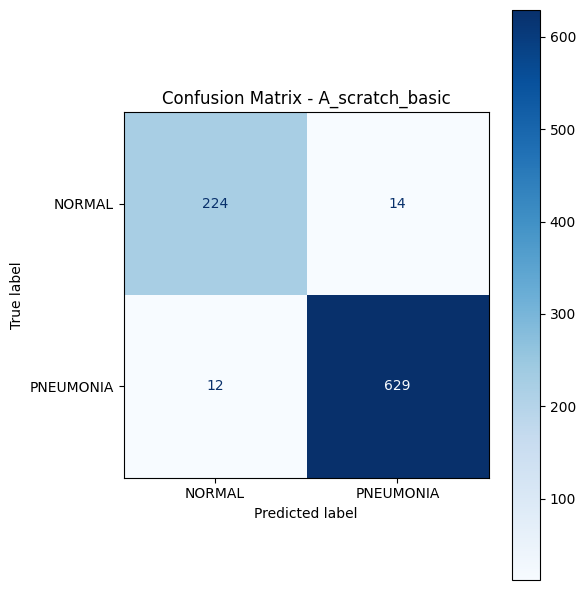

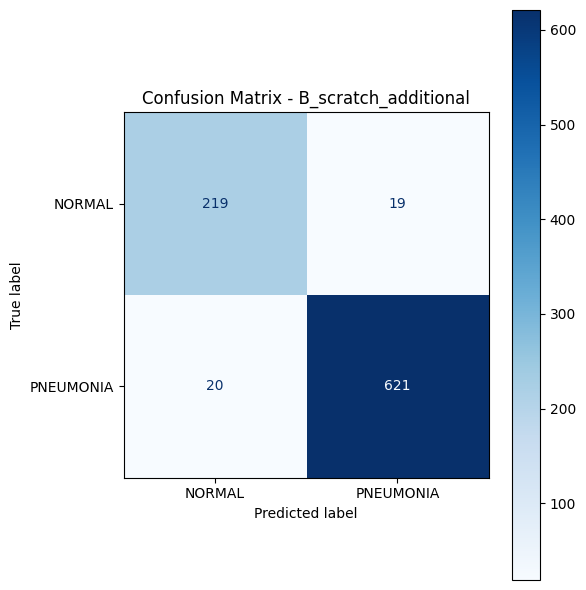

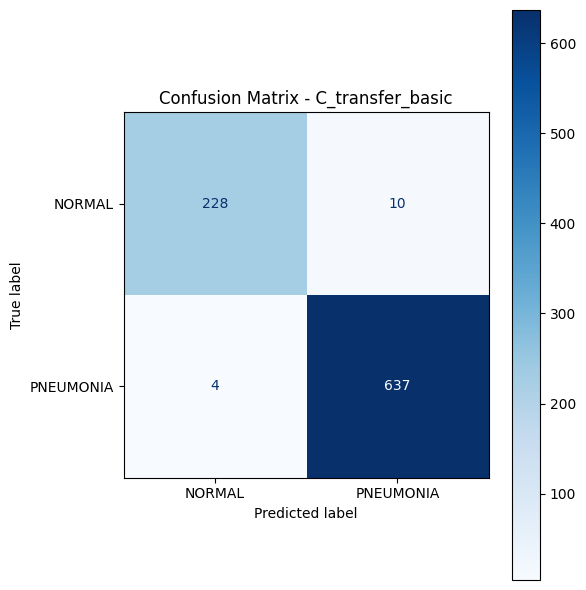

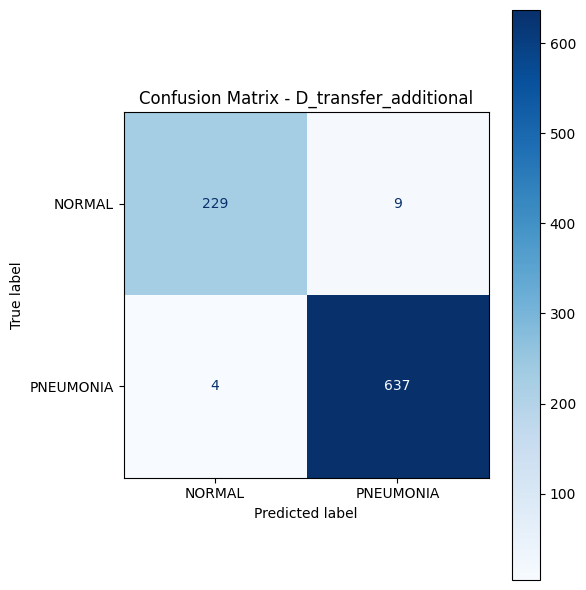

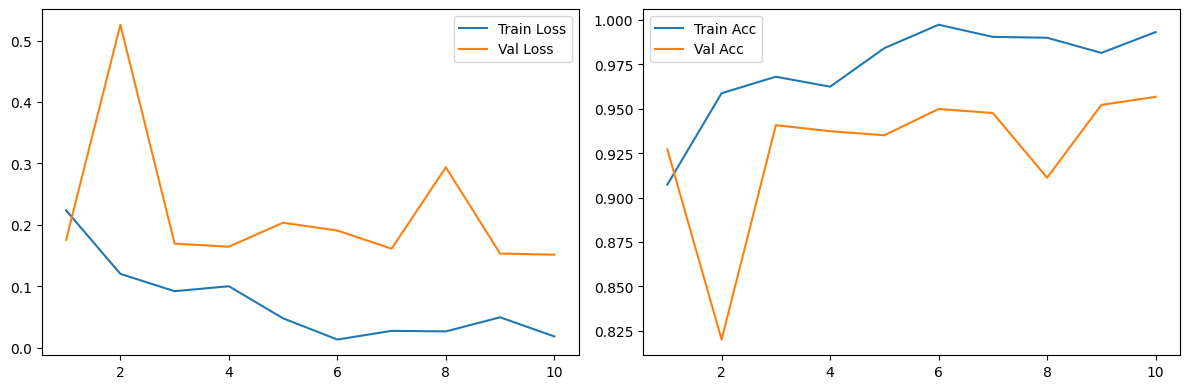

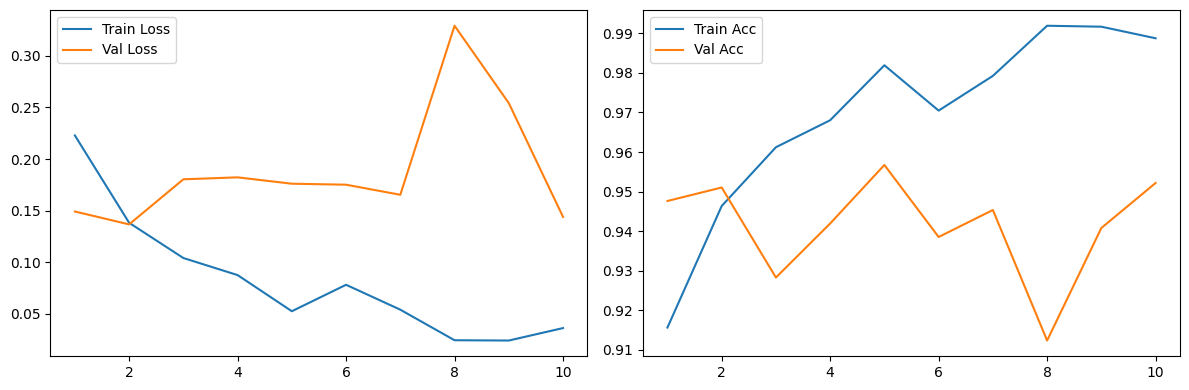

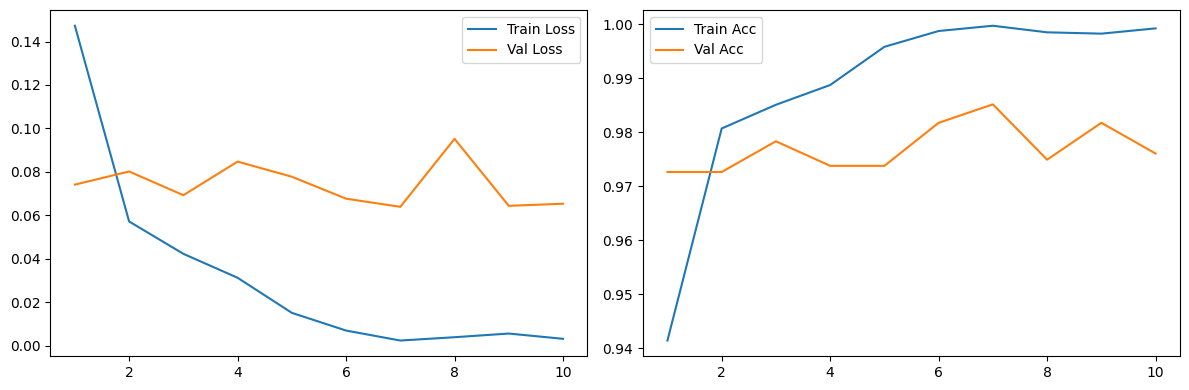

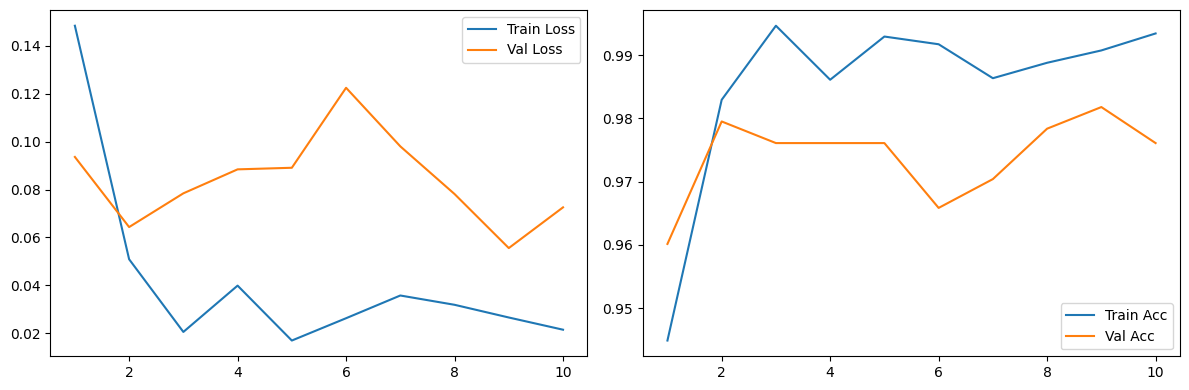

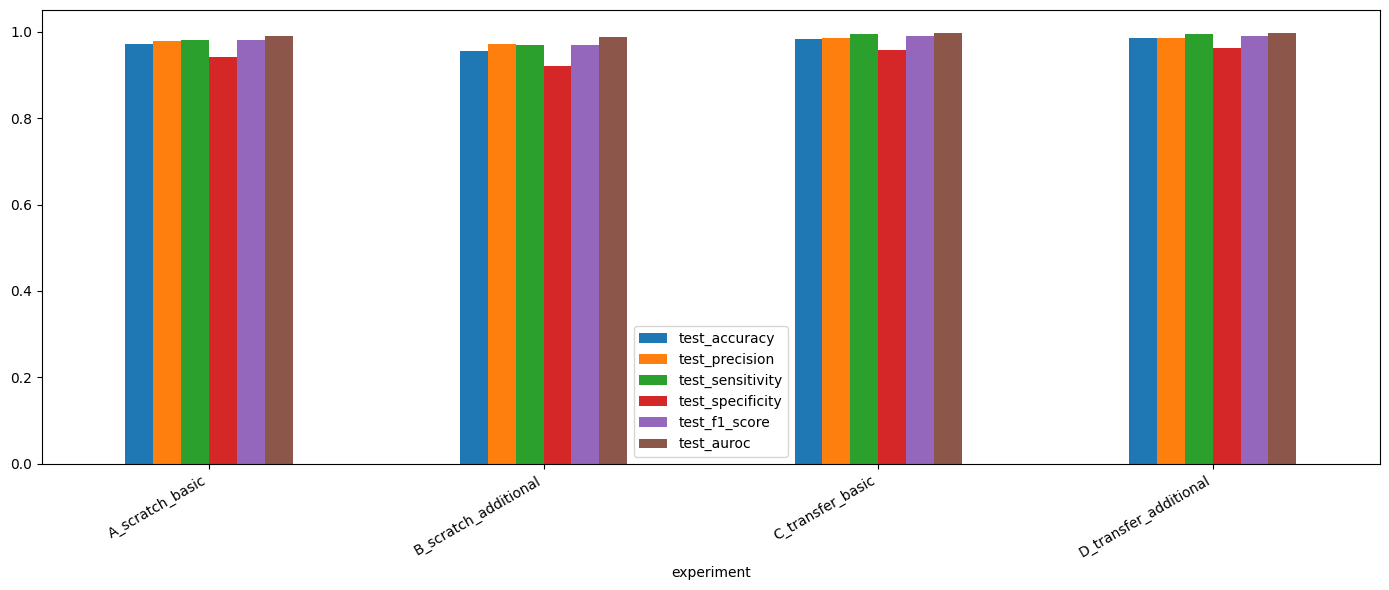

,experiment,best_epoch,best_val_accuracy,test_accuracy,test_precision,test_sensitivity,test_specificity,test_f1_score,test_auroc,true_negative,false_positive,false_negative,true_positive
0,A_scratch_basic,10,0.956720,0.970421,0.978227,0.981279,0.941176,0.979751,0.989633,224,14,12,629
1,B_scratch_additional,5,0.956720,0.955631,0.970313,0.968799,0.920168,0.969555,0.987578,219,19,20,621
2,C_transfer_basic,7,0.985194,0.984073,0.984544,0.993760,0.957983,0.989130,0.997352,228,10,4,637
3,D_transfer_additional,9,0.981777,0.985210,0.986068,0.993760,0.962185,0.989899,0.997417,229,9,4,637


In [67]:
for name, confusion in all_confusions.items():
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=['NORMAL', 'PNEUMONIA']).plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'confusion_matrix_{name}.png', dpi=200, bbox_inches='tight')
    plt.show(); plt.close(fig)

for name, (result, _) in results.items():
    history_df = result['history']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Val Loss'); axes[0].legend()
    axes[1].plot(history_df['epoch'], history_df['train_accuracy'], label='Train Acc')
    axes[1].plot(history_df['epoch'], history_df['val_accuracy'], label='Val Acc'); axes[1].legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'curves_{name}.png', dpi=200, bbox_inches='tight')
    plt.show(); plt.close(fig)

metric_columns = ['test_accuracy', 'test_precision', 'test_sensitivity', 'test_specificity', 'test_f1_score', 'test_auroc']
plot_df = metrics_df.set_index('experiment')[metric_columns]
ax = plot_df.plot(kind='bar', figsize=(14, 6)); ax.set_ylim(0, 1.05); plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparison_test_metrics.png', dpi=200, bbox_inches='tight')
plt.show(); plt.close()

comparison_columns = ['experiment', 'best_epoch', 'best_val_accuracy'] + metric_columns + ['true_negative', 'false_positive', 'false_negative', 'true_positive']
comparison_table = metrics_df[comparison_columns].copy()
comparison_table.to_csv(REPORTS_DIR / 'comparison_table.csv', index=False, encoding='utf-8-sig')
display(comparison_table)

In [68]:
environment_report = f"""Environment Report
Timestamp: {datetime.now().isoformat()}
GPU name: {torch.cuda.get_device_name(0)}
CUDA version: {torch.version.cuda}
PyTorch: {torch.__version__}
Torchvision: {torchvision.__version__}
Pandas: {pd.__version__}
NumPy: {np.__version__}
scikit-learn: {sklearn.__version__}
Random seed: {SEED}
"""
(LOGS_DIR / 'environment_report.txt').write_text(environment_report, encoding='utf-8')
print('تم الحفظ')

تم الحفظ


In [69]:
shutil.make_archive('/content/reports_and_splits', 'zip', REPORTS_DIR)
files.download('/content/reports_and_splits.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
shutil.make_archive('/content/splits_only', 'zip', SPLIT_DIR)
files.download('/content/splits_only.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
shutil.make_archive('/content/figures_only', 'zip', FIGURES_DIR)
files.download('/content/figures_only.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
shutil.make_archive('/content/logs_only', 'zip', LOGS_DIR)
files.download('/content/logs_only.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>